<h1 style="text-align:center;">Binding mode experimental structures</h1>

In [63]:
import glob
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from Bio.PDB import PDBParser, NeighborSearch

from Bio.SeqUtils import seq1


# Segment and epitope distribution 

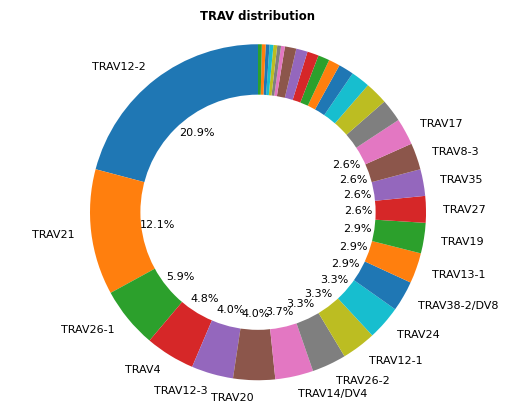

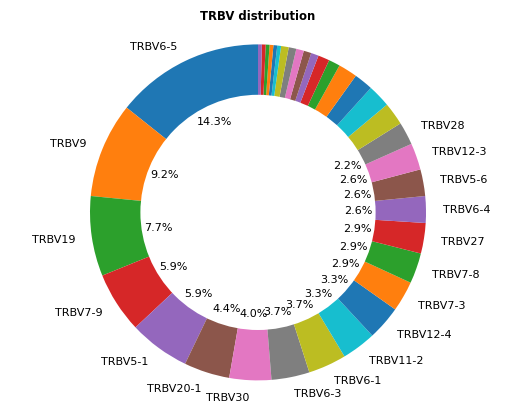

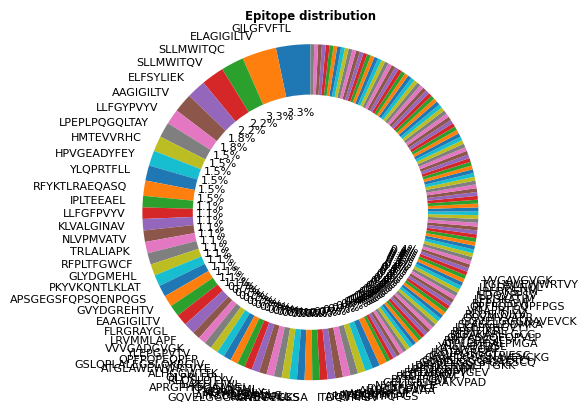

In [64]:
df = pd.read_csv('260305_data.csv') 

variables = ['TRAV', 'TRBV', 'Epitope']
for var in variables:
    fig, ax = plt.subplots()
    
    # count occurrences
    counts = df[var].value_counts()
    wedges, texts, autotexts = ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8})

    # rotate labels
    for i, (text, autotext) in enumerate(zip(texts, autotexts)):
        if i < len(texts)/2:
            pass
        else:
            text.set_text('')
            autotext.set_text('')

    # create donut hole
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    fig.gca().add_artist(centre_circle)

    ax.axis('equal')  # keep circle shape
    plt.title(f"{var} distribution", fontsize='small', fontweight='bold')

    #fig.savefig(f"{var}_donut.pdf", bbox_inches="tight")

# CDR1/2 : peptide / MHC contacts

In [88]:
def extract_cdr_resids(pdb_path, cdr_dict, chain_map={"TRA":"A","TRB":"B"}):
    """
    Extract residue id of CDRs based on the respective sequences.
    """
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("pdb", pdb_path)
    
    cdr_resids = {}
    for cdr_name, cdr_seq in cdr_dict.items():
        # get tcr chain
        chain_id = chain_map[cdr_name.split('_')[-1]]
        chain_obj = structure[0][chain_id]

        # Get all residues with C-alpha
        residues = [res for res in chain_obj if res.id[0] == " " and "CA" in res]

        # Convert 3-letter PDB codes to 1-letter
        seq = "".join([seq1(res.get_resname()) for res in residues])
 
        # find CDR sequence in the chain sequence
        L = len(cdr_seq)
        start_idx = seq.find(cdr_seq)
        if start_idx == -1:
            print(f"Warning: CDR {cdr_name} sequence not found in chain {chain_id} of {pdb_path}")
            return None
        
        end_idx = start_idx + L
        
        # extract cdr resids
        resids = np.array([res.get_id()[1] for res in residues[start_idx:end_idx]])
        cdr_resids[cdr_name] = resids

    return cdr_resids


def compute_cdr_min_distances(pdb_file, cdr_resids, chain_map, sel_epitope):
    """
    Extract minimal CA–CA distances between CDR residues and pMHC.
    """
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("tcr", pdb_file)
    
    # Collect CA atoms of epitope chains
    epitope_atoms = []
    for chain_id in chain_map[sel_epitope]:
        chain = structure[0][chain_id]
        epitope_atoms.extend(
            atom for atom in chain.get_atoms() if atom.get_name() == "CA"
        )
    
    cdr_distances = {}
    
    for cdr, res_nums in cdr_resids.items():
        
        if "TRA" in cdr:
            tcr_chain_id = chain_map["TRA"]
        else:
            tcr_chain_id = chain_map["TRB"]
        
        chain = structure[0][tcr_chain_id]
        distances = []
        
        for res_num in res_nums:
            try:
                res = chain[(' ', res_num, ' ')]
            except KeyError:
                distances.append(np.nan)
                continue
            
            # get CA atom of residue
            if "CA" in res:
                ca_atom = res["CA"]
                
                # compute min CA–CA distance
                min_dist = min(ca_atom - ep_atom for ep_atom in epitope_atoms)
                distances.append(min_dist)
            else:
                distances.append(np.nan)
        
        cdr_distances[cdr] = np.array(distances)
    
    return cdr_distances

def build_dist_matrix(cdr_dist_dict, min_cdr_lengths):
    """
    Build distance matrix with fixed-length CDRs.
    """
    dist_matrix = []
    for pdb, cdrs in cdr_dist_dict.items():
        vec = []
        for cdr_name, distances in cdrs.items():
            L = min_cdr_lengths[cdr_name]
            # first 2 + last L-2
            selected = np.hstack([distances[:2], distances[-(L-2):]])
            vec.extend(selected.flatten())
    
        dist_matrix.append(vec)
    
    return np.array(dist_matrix)
    

In [93]:
topdir = 'pdbs_mhc_align'
df = pd.read_csv('260305_data_structures.csv')
df = df.rename(columns={'CDR1A': 'cdr1_TRA', 'CDR2A': 'cdr2_TRA', 'CDR1B': 'cdr1_TRB', 'CDR2B': 'cdr2_TRB'})

cdr_dist_dict = {}
for idx, row in df.iterrows():
    pdb_file = f'{topdir}/{row.PDB}.pdb'
    print(row.PDB)
    if not os.path.exists(pdb_file):
        continue
    
    if row.MHC == 'classI':
        chain_map={"TRA":"D","TRB":"E", "MHC":["A"], "peptide":"C"}
    else:
        chain_map={"TRA":"D","TRB":"E", "MHC":["A", "B"], "peptide":"C"}

    cdr_dict = {cdr: str(row[cdr]).upper() for cdr in ["cdr1_TRA","cdr2_TRA","cdr1_TRB","cdr2_TRB"]}

    # get cdr resids
    cdr_resids = extract_cdr_resids(pdb_file, cdr_dict, chain_map)

    # get pMHC distance
    peptide_cdr_min_distances = compute_cdr_min_distances(pdb_file, cdr_resids, chain_map, sel_epitope='peptide')
    cdr_dist_dict[row.PDB] = peptide_cdr_min_distances

# minimal CDR lengths
min_cdr_lengths = {}
for cdr_name in ["cdr1_TRA","cdr2_TRA","cdr1_TRB","cdr2_TRB"]:
    min_len = min(cdr_dist_dict[pdb_id][cdr_name].shape[0] for pdb_id in cdr_dist_dict)
    min_cdr_lengths[cdr_name] = min_len

# build distance matrix 
dist_matrix = build_dist_matrix(cdr_dist_dict, min_cdr_lengths)

col_names = [f'{key}.{i+1}' for key in min_cdr_lengths for i in range(min_cdr_lengths[key])]
result = pd.DataFrame(dist_matrix, columns=col_names)
result['PDB'] = cdr_dist_dict.keys()
result = pd.merge(result, df, on='PDB')
result.to_pickle('peptide_dist_matrix.pkl')

1AO7
1BD2
1FYT
1J8H
1MI5
1OGA
1QRN
1QSE
1QSF
1YMM
2AK4
2BNQ
2BNR
2F54
2GJ6
2IAM
2IAN
2NX5
2VLJ
2VLK
2VLR
2WBJ


KeyError: 'C'

In [ ]:
# plot
df = pd.read_pickle()

26
1AO7
1QRN
1QSE
1QSF
2GJ6
3H9S
3HG1
3PWP
3QDG
3QDJ
3QFJ
3VXU
3W0W
4EUP
4FTV
4QOK
5NHT
5NQK
6AM5
6AMU
6EQA
6RP9
7N1F
7Q99
7Q9A
7RTR
22
2BNQ
2BNR
2F54
3VXR
3VXS
5EU6
6PX6
6Q3S
7N2N
7N2O
7N2P
7N2Q
7N2R
7N2S
7R80
8CX4
8F5A
8RYM
8RYN
8RYP
8RYQ
11
3DXA
4OZG
4OZH
6XCP


KeyError: 'C'

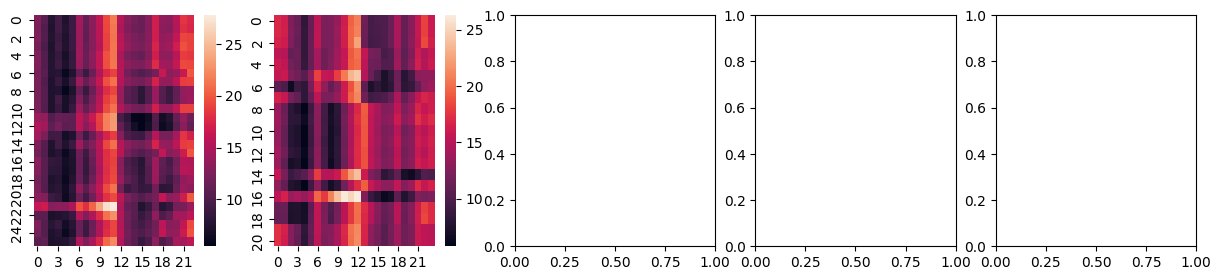

In [ ]:
topdir = 'pdbs_mhc_align'
df = pd.read_csv('260305_data_structures.csv')
df = df.rename(columns={'CDR1A': 'cdr1_TRA', 'CDR2A': 'cdr2_TRA', 'CDR1B': 'cdr1_TRB', 'CDR2B': 'cdr2_TRB'})

n_top = 5
variables = {'TRAV' : [],
             'TRBV' : [],
             #'Epitope' : []
             }

for var in variables:
    counts = df[var].value_counts()
    var_names = counts.index.to_list()
    variables[var].extend(var_names)

for var, varnames in variables.items():
    fig, axes = plt.subplots(1, n_top, figsize=(3*n_top, 3))

    for cnt, varname in enumerate(varnames):
        ax = axes[cnt]
        df_var = df[df[var] == varname]
        print(len(df_var))
        lst = []
        for idx, row in df_var.iterrows():
            pdb_file = f'{topdir}/{row.PDB}.pdb'
            if not os.path.exists(pdb_file):
                continue
            print(row.PDB)
            if row.MHC == 'classI':
                chain_map={"TRA":"D","TRB":"E", "MHC":["A"], "peptide":"C"}
            else:
                chain_map={"TRA":"D","TRB":"E", "MHC":["A", "B"], "peptide":"C"}

            # get residue ids
            if var == 'TRAV':
                cdr_dict = {cdr: str(row[cdr]).upper() for cdr in ["cdr1_TRA","cdr2_TRA","cdr1_TRB","cdr2_TRB"]}
            elif var == 'TRBV':
                
            else:
                cdr_dict = {cdr: str(row[cdr]).upper() for cdr in ["cdr1_TRA","cdr2_TRA","cdr1_TRB","cdr2_TRB"]}

            cdr_resids = extract_cdr_resids(pdb_file, cdr_dict, chain_map)
            
            # get pMHC distance
            peptide_cdr_min_distances = compute_cdr_min_distances(pdb_file, cdr_resids, chain_map, sel_epitope='peptide')
            distances = np.concatenate(list(peptide_cdr_min_distances.values()))
            lst.append(distances)

        arr = np.array(lst)
        sns.heatmap(arr, ax=ax)
    